# EEG Preprocessing

## Overview

You will inspect signal quality, document bad channels, interpolate when positions are known, filter, and re-reference the EEG. The code is a guided skeleton: complete each TODO and justify each decision in your notes.

## Learning objectives

- Identify obvious channel-level problems from traces and spectra.
- Explain interpolation, filtering, and referencing.
- Apply operations to copies so the imported data remain available for comparison.
- Document parameters and save a reproducible preprocessed file.

## Background: Why preprocessing matters

EEG contains brain activity plus drift, line noise, eye movements, muscle activity, movement, and poor electrode contact. Preprocessing changes the data and cannot repair every problem. Choose parameters before looking for the expected condition difference, and document choices that could affect the result.

In [32]:
# Setup cell: run this as provided.
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from mne.preprocessing import ICA, corrmap

mne.set_log_level("WARNING")

## Step 1: Load the raw MNE file

Use `mne.io.read_raw_fif` with `preload=True`; later operations need samples in memory. Make a separate copy named `raw_original` that will not be modified. Print the object and confirm that annotations from Notebook 1 are present.

In [33]:
RAW_PATH = Path("../outputs/raw_motor2.fif")

# TODO: load with preload=True and create an untouched copy.
raw = mne.io.read_raw_fif(RAW_PATH, preload=True)
raw_original = raw.copy()

# TODO: print useful checks: duration, channel count, and annotation count.
raw_original
mne.count_annotations(raw_original.annotations)

C:\Users\evana\AppData\Local\Temp\ipykernel_804\2728602587.py:4: RuntimeWarning: This filename (..\outputs\raw_motor2.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(RAW_PATH, preload=True)


{'left_hand': 60, 'right_hand': 60}

In [34]:
filt_raw = raw.copy().filter(l_freq=1, h_freq=None)
non_periods = mne.preprocessing.annotate_break(
    raw=filt_raw,
    min_break_duration=3.5,
    t_start_after_previous=0,
    t_stop_before_next=0
)
filt_raw.set_annotations(filt_raw.annotations + non_periods)
filt_raw.plot()
filt_raw.set_channel_types({
    'X1':"stim",
    'X2':"stim",
    'X3':"stim",
    'TRG':"stim",
    'A2':"stim"
})


<Raw | raw_motor2.fif, 24 x 303723 (1012.4 s), ~55.6 MiB, data loaded>

In [35]:
ica = ICA(n_components=19, max_iter='auto', random_state=97)
ica.fit(filt_raw, reject=dict(eeg=200e-6))
ica

Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,54 iterations on raw data (238200 samples)
ICA components,19
Available PCA components,19
Channel types,eeg
ICA components marked for exclusion,—


C:\Users\evana\AppData\Local\Temp\ipykernel_804\2079836854.py:1: RuntimeWarning: Not setting position of 1 stim channel found in montage:
['A2']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  filt_raw.set_montage('standard_1020', on_missing='ignore')


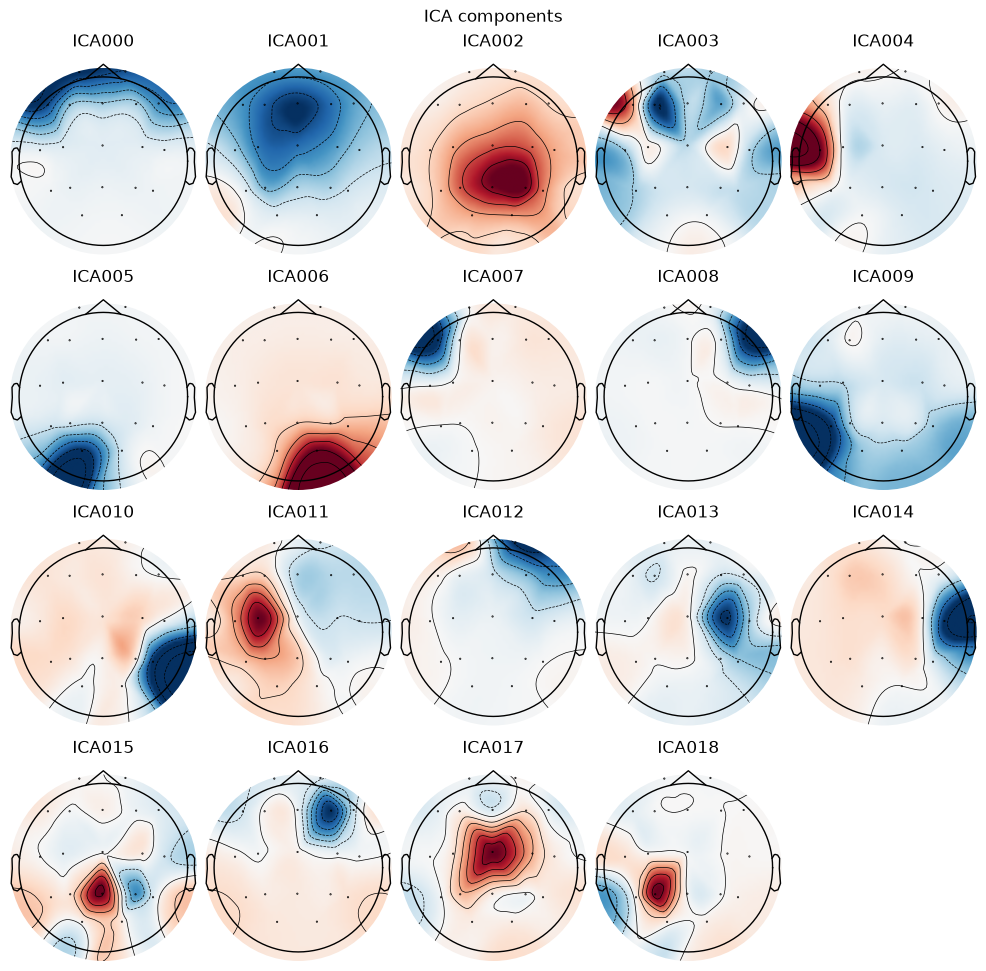

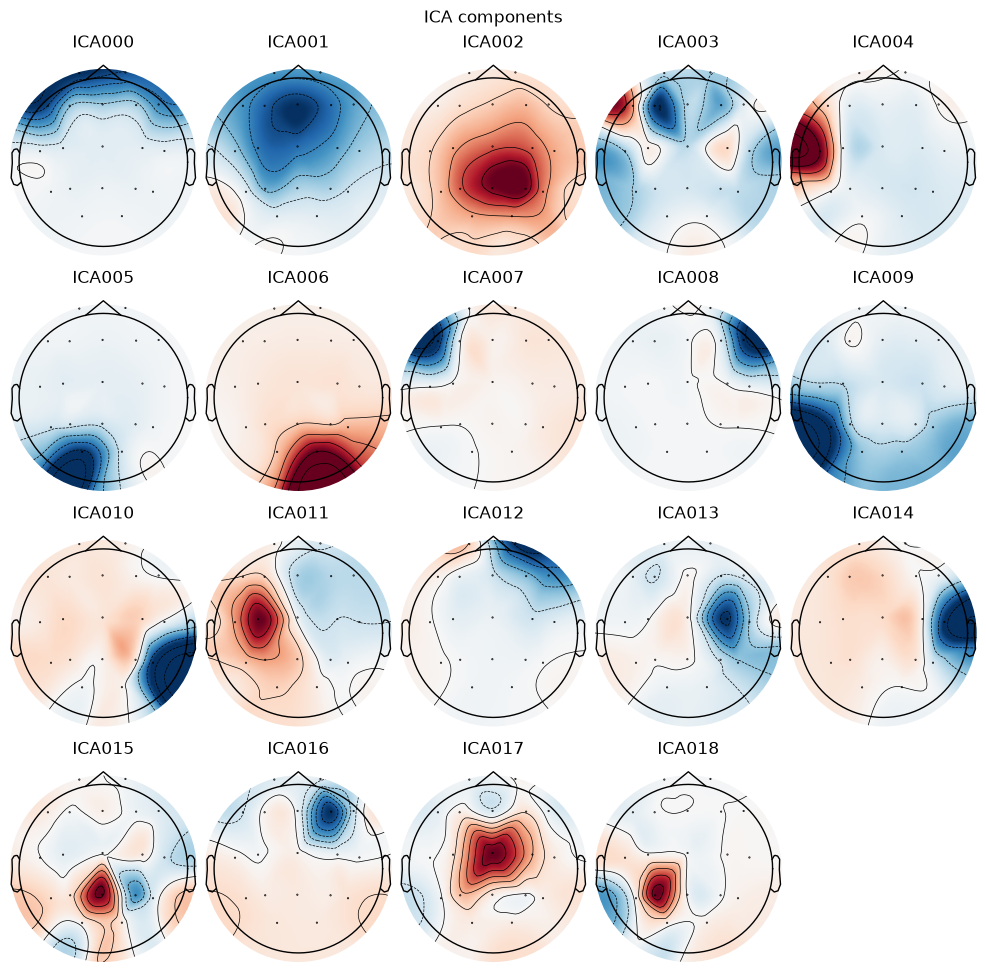

In [47]:
filt_raw.set_montage('standard_1020', on_missing='ignore')
filt_raw.load_data()
ica.fit(filt_raw, reject=dict(eeg=200e-6))
ica.plot_components()

In [50]:
ica.plot_sources(filt_raw)

<mne_qt_browser._pg_figure.MNEQtBrowser(0x2a634748750) at 0x000002A642617C00>

In [52]:
ica.exclude = [0,3,5,6]

In [53]:
ica_raw = raw.copy()

In [64]:
ica.apply(ica_raw)
ICA_PATH = ("../outputs/ica_motor2.fif")
ica_raw.save(ICA_PATH, overwrite=True)

C:\Users\evana\AppData\Local\Temp\ipykernel_804\1132726575.py:3: RuntimeWarning: This filename (c:\Users\evana\Downloads\eeg-analysis-tutorial\Motor_notebooks2\..\outputs\ica_motor2.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  ica_raw.save(ICA_PATH, overwrite=True)


[WindowsPath('c:/Users/evana/Downloads/eeg-analysis-tutorial/Motor_notebooks2/../outputs/ica_motor2.fif')]

In [61]:
ica_raw.info['ch_names']

['P3',
 'C3',
 'F3',
 'Fz',
 'F4',
 'C4',
 'P4',
 'Cz',
 'Pz',
 'Fp1',
 'Fp2',
 'T3',
 'T5',
 'O1',
 'O2',
 'X3',
 'X2',
 'F7',
 'F8',
 'X1',
 'A2',
 'T6',
 'T4',
 'TRG']